In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as mcolors
from matplotlib import rc
import matplotlib.gridspec as gridspec
from fonts_config import set_computer_modern, truncate_colormap
set_computer_modern()
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from PIL import Image
from matplotlib.colors import LogNorm
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib.patches import Rectangle
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False
import glob
import os
from matplotlib import cm


In [2]:
# -----------------------------------------------
# paths
# -----------------------------------------------
n_best=2572

leger=xr.open_dataset("../../FesmData/Leger2024_PaleoGris/output/regions_area_paleogris.nc")
leger2=xr.open_dataset("../../FesmData/Leger2024_PaleoGris/output/paleogris_8km.nc")
yelmo1=xr.open_dataset("../output/timeseries_from2D.nc")
yelmo2=xr.open_dataset("/p/projects/megarun/luciagu/data/tabone2024/processed/regions_area_ensemble.nc")
rg=xr.open_dataset("/p/projects/megarun/luciagu/data/lauritzen2025/Greenland_Basins_PS_v1.4.2_8km.nc")
best=yelmo1.sel(sim=n_best)
topo = xr.open_dataset("/p/projects/megarun/ice_data/Greenland/GRL-8KM/GRL-8KM_TOPO-M17.nc")
best2=xr.open_dataset(f"/p/projects/megarun/luciagu/data/tabone2024/ensemble_reduced/{n_best}/yelmo2D_reduced.nc")
S = xr.open_dataset("../scoring/scores/scores2.nc")

In [3]:
region_ids=leger.region.values
min_err = 1000

sigma2 = xr.where((leger2.err == 0)|(leger2.err == np.nan), min_err, leger2.err) * 1e-3
sigma2=sigma2.where(leger2.age*1e-3<14)
diff = leger2.age*1e-3 - best2.isochrone.where(leger2.age*1e-3<14)
chi2 = (diff**2) / (sigma2**2)
rmse = np.sqrt(diff**2)

chi2_regions=[]
rmse_ens=[]
for i, r in enumerate(region_ids):
    chi2_values = np.array(chi2.where(rg.mask==r)).flatten()
    chi2_clean = chi2_values[~np.isnan(chi2_values)]
    chi_mean = np.mean(chi2_clean)
    chi2_regions.append(chi_mean)
    rmse_ens.append(rmse.where(rg.mask==r).mean())

chi2_regions = np.array(chi2_regions)
rmse_ens = np.array(rmse_ens)
rmse_ens

array([3.82682927, 0.47440283, 0.28620201, 0.11502347, 1.63805824,
       0.55340672, 0.72986784])

/tmp/ipykernel_171363/2153500941.py:84: UserWarning: linewidths is ignored by contourf
  ax_map.contourf(rg["xc"], rg["yc"], rg.mask.where(rg.mask>1), levels=np.linspace(0,7,8), cmap="Pastel1", linewidths=0.5)
/tmp/ipykernel_171363/2153500941.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


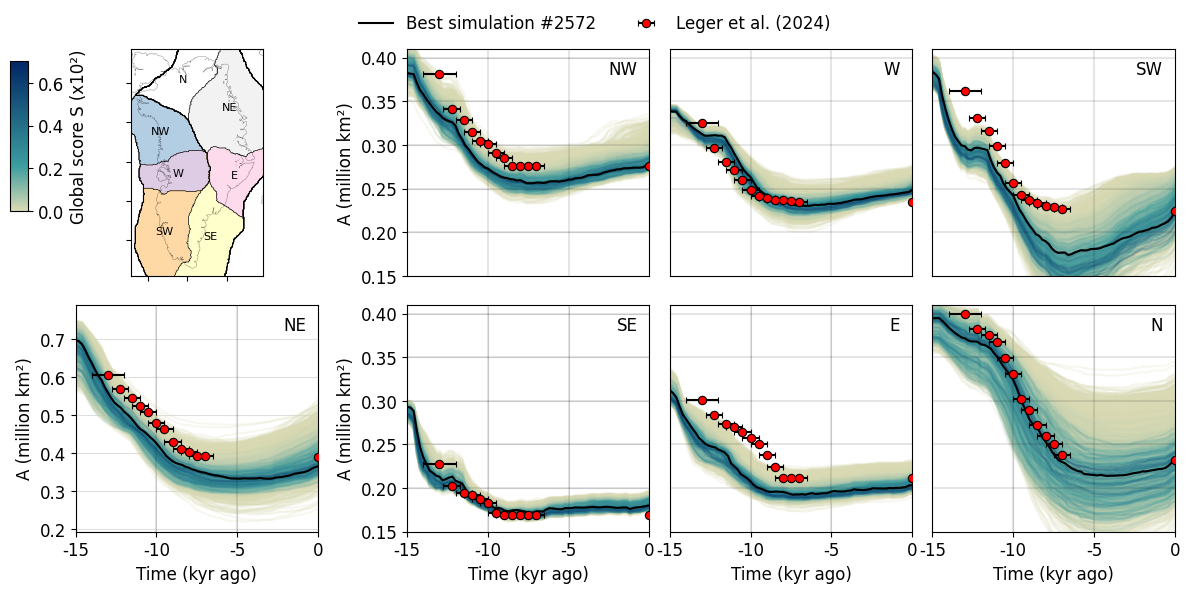

In [4]:
# Nombres de las regiones
region_names = ["NW", "W", "SW","NE","SE","E","N"]
sorted_sim_indices = S.sim.sortby(S.S).values
# region_ids=leger.region.values
region_ids=np.array([2, 3, 4, 7, 5, 6, 8])

colors = ["#D9DAB3", "#3C9D9F", "#002665"]
nodes = [0, 0.3, 1.0]
cmap = mcolors.LinearSegmentedColormap.from_list("custom_warm", list(zip(nodes, colors)))
norm = mcolors.Normalize(vmin=S.S.values .min()*100, vmax=S.S.values .max()*100)

# fig, axes = plt.subplots(2, 4, figsize=(13, 6))
# axes = axes.flatten()

fig = plt.figure(figsize=(12, 6))

widths = [1, 0.2, 1, 1, 1] 
gs = gridspec.GridSpec(2, 5, width_ratios=widths)
axes = []
for row in range(2):
    for col in [0, 2, 3, 4]:
        ax = fig.add_subplot(gs[row, col])
        axes.append(ax)


for i, r in enumerate(np.array([2, 3, 4, 7, 5, 6, 8])):
    ax = axes[i+1]
    color_s = cmap(norm(S.S.sel(sim=i).values*100))
    # yelmo
    j=0
    for sim_idx in sorted_sim_indices:
        color_s = cmap(norm(S.S.sel(sim=sim_idx).values*100))
        if j==0:
            ax.plot(
            yelmo1["time"]*1e-3, 
            yelmo1["A"].sel(sim=sim_idx, region=r), 
            "-", color=color_s, alpha=0.2)
        else:
            ax.plot(
            yelmo1["time"]*1e-3, 
            yelmo1["A"].sel(sim=sim_idx, region=r), 
            "-", color=color_s, alpha=0.2)
        j=j+1
    # Leger (2024)
    leg=leger.sel(region=r)
    ax.errorbar(-leg["time"] * 1e-3,leg.A,xerr=leg.time_err*1e-3,fmt='o',ecolor='black',
                markersize=6,markerfacecolor='red',markeredgecolor='black',markeredgewidth=0.8,
                capsize=2,zorder=60,label="Leger et al. (2024)")
    
    # best simulation
    ax.plot(best.time*1e-3,best.A.sel(region=r), "-", color="black",label=f"Best simulation #{n_best}")
    # names
    ax.text(0.95, 0.95, f"{region_names[i]}",#\nRMSE = {rmse_ens[i]:.2f} kyr"
        transform=ax.transAxes,  
        ha='right', va='top')
    ax.grid(alpha=0.4)
    if r!=7: 
        ax.set_ylim(0.15,0.41)
        for v in [0.2,0.25,0.3,0.35,0.4]:
            ax.axhline(y=v, color='black', linestyle='-', alpha=0.1)
    ax.set_xlim(-15,0)
    if i >= 3:
        ax.set_xlabel("Time (kyr ago)")
    for v in [-20, -15, -10, -5]:
        ax.axvline(x=v, color='black', linestyle='-', alpha=0.1)

axes[1].set_ylabel("A (million km²)")
axes[4].set_ylabel("A (million km²)")
axes[5].set_ylabel("A (million km²)")

axes[2].set_yticks([])
axes[3].set_yticks([])
axes[6].set_yticks([])
axes[7].set_yticks([])

axes[1].set_xticks([])
axes[2].set_xticks([])
axes[3].set_xticks([])
# --- mapa de regiones ---
ax_map = axes[0]

# Contornos de regiones
ax_map.contour(rg["xc"], rg["yc"], rg.mask, colors='black', linewidths=0.5)
ax_map.contourf(rg["xc"], rg["yc"], rg.mask.where(rg.mask>1), levels=np.linspace(0,7,8), cmap="Pastel1", linewidths=0.5)

ax_map.contour(topo.xc,topo.yc,topo.z_srf,levels=np.linspace(0,100,1), colors='black', linewidths=0.3, alpha=0.5)

ax_map.set_xlabel("")
ax_map.set_ylabel("")
ax_map.set_aspect('equal')
ax_map.set_xticklabels([]) 
ax_map.set_yticklabels([]) 
ax_map.grid(False)

# Añadir nombres de región en lugar de números
for i, r in enumerate(region_ids):
    ys, xs = np.where(rg.mask == r)
    if len(xs) > 0:
        cx = rg["xc"].values[xs].mean()
        cy = rg["yc"].values[ys].mean()
        ax_map.text(cx, cy, region_names[i], color="black", ha="center", va="center",
                    fontsize=8)

# --- Quitar subplots vacíos si los hubiera ---
for j in range(len(region_ids) + 1, len(axes)):
    axes[j].axis("off")

# --- Leyenda global ---
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)

cbar_ax = fig.add_axes([0.01, 0.65, 0.015, 0.25])
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax)
cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, orientation='vertical')
cb.set_label('Global score S (x10²)')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(wspace=0.1) 

plt.show()
fig.savefig(f"../figs_final/fig3_{n_best}ensemble_isochrones.png", dpi=300)